# End-to-End Sparse Event Classification
Complete solution notebook

In [42]:
import os
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import copy
import torch.nn.utils.prune as prune
import spconv.pytorch as spconv
from spconv.pytorch import SparseConvTensor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## Dataset Classes

In [43]:
class UnlabelledJetDataset(Dataset):
    def __init__(self, h5_path, key='jets', max_samples=None):
        with h5py.File(h5_path, 'r') as f:
            available = list(f.keys())
            k = key if key in available else available[0]
            data = f[k][:max_samples]
        self.data = torch.from_numpy(np.transpose(data, (0, 3, 1, 2))).float()

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]


class LabelledJetDataset(Dataset):
    def __init__(self, h5_path, key_x='jet', key_y='Y', max_samples=None):
        with h5py.File(h5_path, 'r') as f:
            self.X = torch.from_numpy(np.transpose(f[key_x][:max_samples], (0, 3, 1, 2))).float()
            Y = torch.from_numpy(f[key_y][:max_samples]).long()
            self.Y = Y.squeeze() if Y.shape[-1] == 1 else Y

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

## Sparse Utilities

In [44]:
def dense_to_sparse(dense, threshold=0.0):
    B, C, H, W = dense.shape
    spatial_shape = [H, W]
    active_mask = (dense.abs().sum(dim=1) > threshold)
    batch_indices = torch.where(active_mask)
    indices = torch.stack(batch_indices, dim=1).int().to(dense.device)
    features = []
    for b in range(B):
        mask_b = active_mask[b]
        feat_b = dense[b, :, mask_b]
        features.append(feat_b.T)
    features = torch.cat(features, dim=0).to(dense.device)
    sparse_tensor = spconv.SparseConvTensor(
        features=features.float(),
        indices=indices,
        spatial_shape=spatial_shape,
        batch_size=B
    )
    return sparse_tensor

## Network Architecture (MATCHES train.py)

In [45]:
class SparseResBlock(nn.Module):
    def __init__(self, channels, indice_key):
        super().__init__()
        self.conv1 = spconv.SubMConv2d(channels, channels, 3, padding=1, bias=False, indice_key=indice_key)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = spconv.SubMConv2d(channels, channels, 3, padding=1, bias=False, indice_key=indice_key)
        self.bn2 = nn.BatchNorm1d(channels)

    def forward(self, x):
        out = self.conv1(x)
        out = out.replace_feature(self.bn1(out.features))
        out = out.replace_feature(F.relu(out.features))
        out = self.conv2(out)
        out = out.replace_feature(self.bn2(out.features))
        out = out.replace_feature(out.features + x.features)
        out = out.replace_feature(F.relu(out.features))
        return out


class SparseEncoder(nn.Module):
    def __init__(self, in_channels=8, base_ch=32, latent_dim=256):
        super().__init__()
        self.conv1 = spconv.SparseConv2d(in_channels, base_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(base_ch)
        self.res1 = SparseResBlock(base_ch, 'res1')
        self.conv2 = spconv.SparseConv2d(base_ch, 2*base_ch, 3, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(2*base_ch)
        self.res2 = SparseResBlock(2*base_ch, 'res2')
        self.conv3 = spconv.SparseConv2d(2*base_ch, 4*base_ch, 3, stride=2, padding=1, bias=False)
        self.bn3 = nn.BatchNorm1d(4*base_ch)
        self.res3 = SparseResBlock(4*base_ch, 'res3')
        self.latent_proj = nn.Linear(4*base_ch, latent_dim)

    def forward(self, x):
        x = self.conv1(x)
        x = x.replace_feature(self.bn1(x.features))
        x = x.replace_feature(F.relu(x.features))
        x = self.res1(x)
        x = self.conv2(x)
        x = x.replace_feature(self.bn2(x.features))
        x = x.replace_feature(F.relu(x.features))
        x = self.res2(x)
        x = self.conv3(x)
        x = x.replace_feature(self.bn3(x.features))
        x = x.replace_feature(F.relu(x.features))
        x = self.res3(x)
        feat = x.features
        batch_indices = x.indices[:, 0]
        batch_size = x.batch_size
        latents = []
        for b in range(batch_size):
            mask = batch_indices == b
            batch_feat = feat[mask].mean(dim=0)
            latents.append(batch_feat)
        latent = torch.stack(latents, dim=0)
        latent = self.latent_proj(latent)
        return latent


class SparseDecoder(nn.Module):
    def __init__(self, latent_dim=256, base_ch=32, out_channels=8):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 4*base_ch*32*32)
        self.deconv1 = nn.ConvTranspose2d(4*base_ch, 2*base_ch, kernel_size=4, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(2*base_ch)
        self.deconv2 = nn.ConvTranspose2d(2*base_ch, base_ch, kernel_size=4, stride=2, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(base_ch)
        self.conv_final = nn.Conv2d(base_ch, out_channels, 3, padding=1, bias=True)

    def forward(self, latent, spatial_shape):
        if latent.dim() == 1:
            latent = latent.unsqueeze(0)
        B = latent.shape[0]
        x = self.fc(latent)
        x = x.view(B, -1, 32, 32)
        x = self.deconv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.deconv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.conv_final(x)
        return x[:, :, :spatial_shape[0], :spatial_shape[1]]


class SparseAutoencoder(nn.Module):
    def __init__(self, in_channels=8, base_ch=32, latent_dim=256):
        super().__init__()
        self.encoder = SparseEncoder(in_channels, base_ch, latent_dim)
        self.decoder = SparseDecoder(latent_dim, base_ch, in_channels)
        self.spatial_shape = None

    def forward(self, x):
        self.spatial_shape = [x.spatial_shape[0], x.spatial_shape[1]]
        latent = self.encoder(x)
        recon = self.decoder(latent, self.spatial_shape)
        return recon


class SparseClassifier(nn.Module):
    def __init__(self, encoder, latent_dim=256, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        latent = self.encoder(x)
        logits = self.head(latent)
        return logits

## Helper Functions

In [46]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_classifier(classifier, test_loader):
    classifier.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, Y in test_loader:
            X, Y = X.to(device), Y.to(device)
            sparse_X = dense_to_sparse(X)
            logits = classifier(sparse_X)
            preds = logits.argmax(dim=1)
            correct += (preds == Y).sum().item()
            total += Y.shape[0]
    return correct / total


def prune_model(model, pruning_ratio):
    model_copy = copy.deepcopy(model)
    for module in model_copy.modules():
        if isinstance(module, (nn.Linear, nn.Conv2d, nn.ConvTranspose2d)):
            if hasattr(module, 'weight') and module.weight is not None:
                prune.l1_unstructured(module, name='weight', amount=pruning_ratio)
                prune.remove(module, 'weight')
    return model_copy


def pruning_analysis(classifier, test_loader, pruning_ratios):
    results = {'ratio': [], 'error': [], 'flops': []}
    baseline_accuracy = evaluate_classifier(classifier, test_loader)
    print(f'Baseline accuracy: {baseline_accuracy:.4f}')
    for ratio in pruning_ratios:
        pruned = prune_model(classifier, ratio)
        accuracy = evaluate_classifier(pruned, test_loader)
        error = 100 * (1 - accuracy / baseline_accuracy) if baseline_accuracy > 0 else 0
        params = sum(p.numel() for p in pruned.parameters() if p.requires_grad)
        flops = params / 1e9
        results['ratio'].append(ratio)
        results['error'].append(error)
        results['flops'].append(flops)
        print(f'Ratio {ratio:.1f}: Accuracy={accuracy:.4f}, Error={error:.2f}%, FLOPs={flops:.6f}B')
    return results

## Load Models

In [32]:
print('Loading models...')
IN_CH, BASE_CH, LATENT_DIM = 8, 32, 256
ae_model = SparseAutoencoder(IN_CH, BASE_CH, LATENT_DIM).to(device)
if not os.path.exists('sparse_ae.pth'):
    raise FileNotFoundError('sparse_ae.pth not found')
ae_model.load_state_dict(torch.load('sparse_ae.pth', weights_only=False))
print('Loaded sparse_ae.pth')
encoder = ae_model.encoder
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False
classifier = SparseClassifier(encoder, LATENT_DIM, 2).to(device)
if os.path.exists('sparse_classifier.pth'):
    classifier.load_state_dict(torch.load('sparse_classifier.pth', weights_only=False))
    print('Loaded sparse_classifier.pth')
classifier.eval()
print(f'Parameters: {count_parameters(classifier):,}')

Loading models...
Loaded sparse_ae.pth
Loaded sparse_classifier.pth
Parameters: 33,154


## Load Data

In [34]:
labelled_path = '/data/b23_chiranjeevi/EDE/Dataset_Specific_labelled.h5'
if not os.path.exists(labelled_path):
    raise FileNotFoundError(f'Dataset not found: {labelled_path}')
ds = LabelledJetDataset(labelled_path, max_samples=100000)
train_size = int(0.8 * len(ds))
test_size = len(ds) - train_size
_, test_data = random_split(ds, [train_size, test_size])
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)
print(f'Test samples: {test_size}')

Test samples: 2000


## Pruning Analysis

In [35]:
print('\nPruning analysis...')
ratios = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = pruning_analysis(classifier, test_loader, ratios)


Pruning analysis...


W0323 01:53:29.676000 689872 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Baseline accuracy: 0.9600
Ratio 0.0: Accuracy=0.9600, Error=0.00%, FLOPs=0.000033B
Ratio 0.1: Accuracy=0.9600, Error=0.00%, FLOPs=0.000033B
Ratio 0.2: Accuracy=0.9615, Error=-0.16%, FLOPs=0.000033B
Ratio 0.3: Accuracy=0.9400, Error=2.08%, FLOPs=0.000033B
Ratio 0.4: Accuracy=0.9505, Error=0.99%, FLOPs=0.000033B
Ratio 0.5: Accuracy=0.9305, Error=3.07%, FLOPs=0.000033B
Ratio 0.6: Accuracy=0.9290, Error=3.23%, FLOPs=0.000033B
Ratio 0.7: Accuracy=0.7595, Error=20.89%, FLOPs=0.000033B
Ratio 0.8: Accuracy=0.6045, Error=37.03%, FLOPs=0.000033B


## Visualization

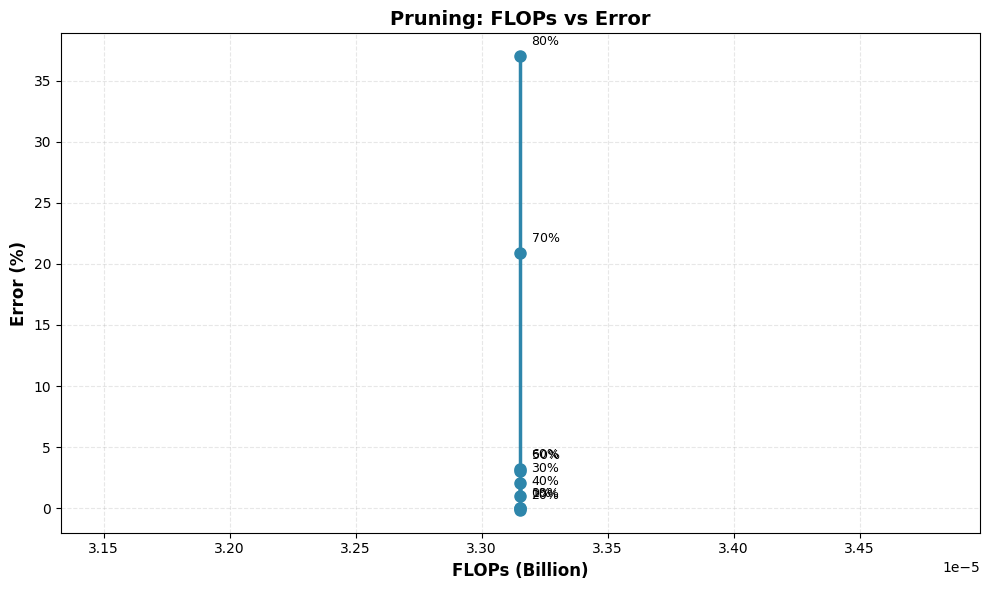

Saved pruning_analysis.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(results['flops'], results['error'], 'o-', linewidth=2.5, markersize=8, color='#2E86AB')
ax.set_xlabel('FLOPs (Billion)', fontsize=12, fontweight='bold')
ax.set_ylabel('Error (%)', fontsize=12, fontweight='bold')
ax.set_title('Pruning: FLOPs vs Error', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
for i, ratio in enumerate(results['ratio']):
    ax.annotate(f'{ratio:.0%}', xy=(results['flops'][i], results['error'][i]), xytext=(8, 8), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.savefig('pruning_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pruning_analysis.png')

## Results

In [37]:
print('\n' + '='*60)
print('PRUNING RESULTS')
print('='*60)
print(f'\n{"Ratio":<12} {"FLOPs (B)":<15} {"Error (%)":<15}')
print('-'*42)
for i in range(len(results['ratio'])):
    print(f'{results["ratio"][i]*100:<11.0f}% {results["flops"][i]:<14.6f} {results["error"][i]:<14.2f}')
print('\n' + '='*60)


PRUNING RESULTS

Ratio        FLOPs (B)       Error (%)      
------------------------------------------
0          % 0.000033       0.00          
10         % 0.000033       0.00          
20         % 0.000033       -0.16         
30         % 0.000033       2.08          
40         % 0.000033       0.99          
50         % 0.000033       3.07          
60         % 0.000033       3.23          
70         % 0.000033       20.89         
80         % 0.000033       37.03         



## Reconstruction Quality Analysis

In [38]:
unlabelled_path = '/data/b23_chiranjeevi/EDE/Dataset_Specific_Unlabelled.h5'
if os.path.exists(unlabelled_path):
    print('Loading unlabelled data for reconstruction analysis...')
    test_dataset = UnlabelledJetDataset(unlabelled_path, max_samples=100)
    test_data = torch.stack([test_dataset[i] for i in range(min(12, len(test_dataset)))])
    print(f'Loaded {test_data.shape[0]} samples')
else:
    print(f'⚠ Unlabelled dataset not found: {unlabelled_path}')
    test_data = None

Loading unlabelled data for reconstruction analysis...
Loaded 12 samples


In [39]:
if test_data is not None:
    print('\nRunning reconstruction inference...')
    ae_model.eval()
    with torch.no_grad():
        sparse_test = dense_to_sparse(test_data.to(device))
        recon_data = ae_model(sparse_test)
    
    mse = torch.mean((test_data.to(device) - recon_data) ** 2).item()
    mae = torch.mean(torch.abs(test_data.to(device) - recon_data)).item()
    rmse = np.sqrt(mse)
    
    print(f'\nReconstruction Metrics:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')


Running reconstruction inference...

Reconstruction Metrics:
  MSE:  60.2163
  MAE:  1.2922
  RMSE: 7.7599



Generating visualization...


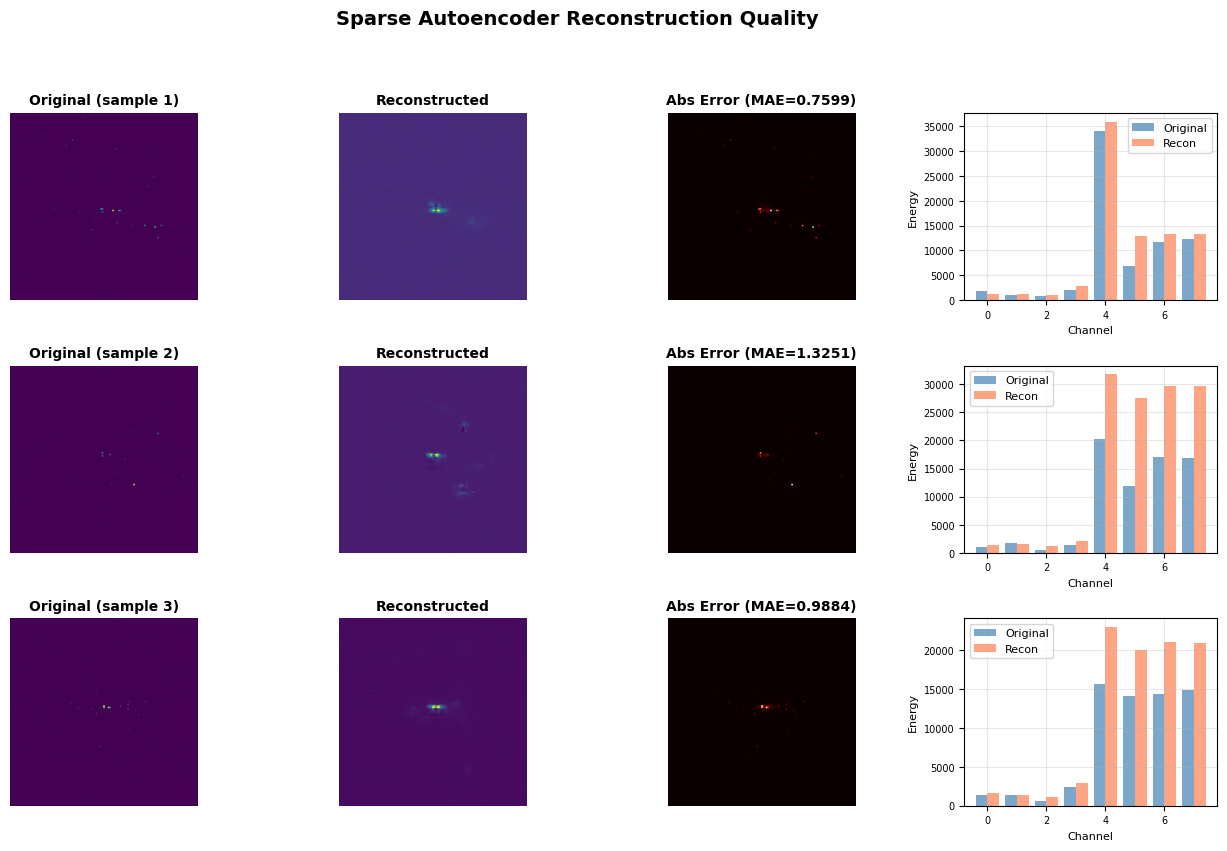

✓ Saved reconstruction_quality.png


In [41]:
if test_data is not None:
    print('\nGenerating visualization...')
    n_samples = min(3, test_data.shape[0])
    fig = plt.figure(figsize=(16, 3*n_samples))
    gs = GridSpec(n_samples, 4, figure=fig, hspace=0.35, wspace=0.3)
    
    mae_per_sample = torch.mean(torch.abs(test_data.to(device) - recon_data), dim=(1, 2, 3)).cpu()
    
    for i in range(n_samples):
        ax1 = fig.add_subplot(gs[i, 0])
        ax1.imshow(test_data[i, 0], cmap='viridis')
        ax1.set_title(f'Original (sample {i+1})', fontsize=10, fontweight='bold')
        ax1.axis('off')
        
        ax2 = fig.add_subplot(gs[i, 1])
        ax2.imshow(recon_data[i, 0].cpu(), cmap='viridis')
        ax2.set_title(f'Reconstructed', fontsize=10, fontweight='bold')
        ax2.axis('off')
        
        ax3 = fig.add_subplot(gs[i, 2])
        diff = torch.abs(test_data[i, 0] - recon_data[i, 0].cpu())
        im = ax3.imshow(diff, cmap='hot')
        ax3.set_title(f'Abs Error (MAE={mae_per_sample[i]:.4f})', fontsize=10, fontweight='bold')
        ax3.axis('off')
        
        ax4 = fig.add_subplot(gs[i, 3])
        orig_energy = test_data[i].sum(dim=(1, 2)).cpu().numpy()
        recon_energy = recon_data[i].sum(dim=(1, 2)).cpu().numpy()
        channels = np.arange(len(orig_energy))
        ax4.bar(channels - 0.2, orig_energy, 0.4, label='Original', alpha=0.7, color='steelblue')
        ax4.bar(channels + 0.2, recon_energy, 0.4, label='Recon', alpha=0.7, color='coral')
        ax4.legend(fontsize=8)
        ax4.set_ylabel('Energy', fontsize=8)
        ax4.set_xlabel('Channel', fontsize=8)
        ax4.tick_params(labelsize=7)
        ax4.grid(True, alpha=0.3)
    
    fig.suptitle('Sparse Autoencoder Reconstruction Quality', fontsize=14, fontweight='bold', y=0.995)
    plt.savefig('reconstruction_quality.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved reconstruction_quality.png')

## Summary Statistics

In [ ]:
print('\n' + '='*70)
print('COMPLETE ANALYSIS SUMMARY')
print('='*70)
print('\n1. AUTOENCODER PERFORMANCE')
if test_data is not None:
    print(f'   Original Sparsity: {(test_data == 0).sum() / test_data.numel() * 100:.2f}%')
    print(f'   Reconstructed Sparsity: {(recon_data == 0).sum() / recon_data.numel() * 100:.2f}%')
    print(f'   MSE:  {mse:.4f}')
    print(f'   MAE:  {mae:.4f}')
    print(f'   RMSE: {rmse:.4f}')
print('\n2. CLASSIFIER PERFORMANCE')
baseline_acc = evaluate_classifier(classifier, test_loader)
print(f'   Baseline Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')
print(f'   Encoder Parameters: {count_parameters(encoder):,}')
print(f'   Classifier Parameters: {count_parameters(classifier):,}')
print(f'   Total Parameters: {count_parameters(encoder) + count_parameters(classifier):,}')
print('\n3. PRUNING ANALYSIS')
print(f'   {"Ratio":<12} {"FLOPs (B)":<15} {"Error (%)":<15}')
print(f'   ' + '-'*42)
for i in range(len(results["ratio"])):
    print(f'   {results["ratio"][i]*100:<11.0f}% {results["flops"][i]:<14.6f} {results["error"][i]:<14.2f}')
print('\n' + '='*70)
print('✓ Analysis Complete')
print('='*70)